In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
BASE_PATH = "D:/PomegranateGuard"

DATASET_PATH = os.path.join(BASE_PATH, "dataset")
MODEL_PATH = os.path.join(BASE_PATH, "model")
TRAINING_PATH = os.path.join(BASE_PATH, "training")
EVAL_PATH = os.path.join(BASE_PATH, "evaluation")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(TRAINING_PATH, exist_ok=True)
os.makedirs(EVAL_PATH, exist_ok=True)


In [3]:

print("Loading dataset...")

X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(DATASET_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(DATASET_PATH, "X_test.npy"))

y_train = np.load(os.path.join(DATASET_PATH, "y_train.npy"))
y_val   = np.load(os.path.join(DATASET_PATH, "y_val.npy"))
y_test  = np.load(os.path.join(DATASET_PATH, "y_test.npy"))

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Loading dataset...
Train: (3938, 224, 224, 3)
Val: (844, 224, 224, 3)
Test: (844, 224, 224, 3)


In [4]:

print("\nBuilding CNN model...")

num_classes = 4

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')

])

model.summary()


Building CNN model...


D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining CNN baseline model...")

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)



Training CNN baseline model...
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.7141 - loss: 0.7155 - val_accuracy: 0.8507 - val_loss: 0.3910
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9149 - loss: 0.2548 - val_accuracy: 0.9692 - val_loss: 0.0893
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9632 - loss: 0.1225 - val_accuracy: 0.9585 - val_loss: 0.1270
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9731 - loss: 0.0923 - val_accuracy: 0.9739 - val_loss: 0.0949
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9777 - loss: 0.0736 - val_accuracy: 0.9799 - val_loss: 0.0667
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 123s 994ms/step - accuracy: 0.9845 - loss: 0.0526 - val_accuracy: 0.9751 - val_loss: 0.1110
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 142s 994ms/step - accuracy: 0.9850 - loss: 0.0494 - val_accuracy: 0.9858 - val_loss: 0.0466
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accu

In [6]:
model.save(os.path.join(MODEL_PATH, "pomegranate_cnn_baseline.h5"))
print("Model saved successfully!")

Model saved successfully!


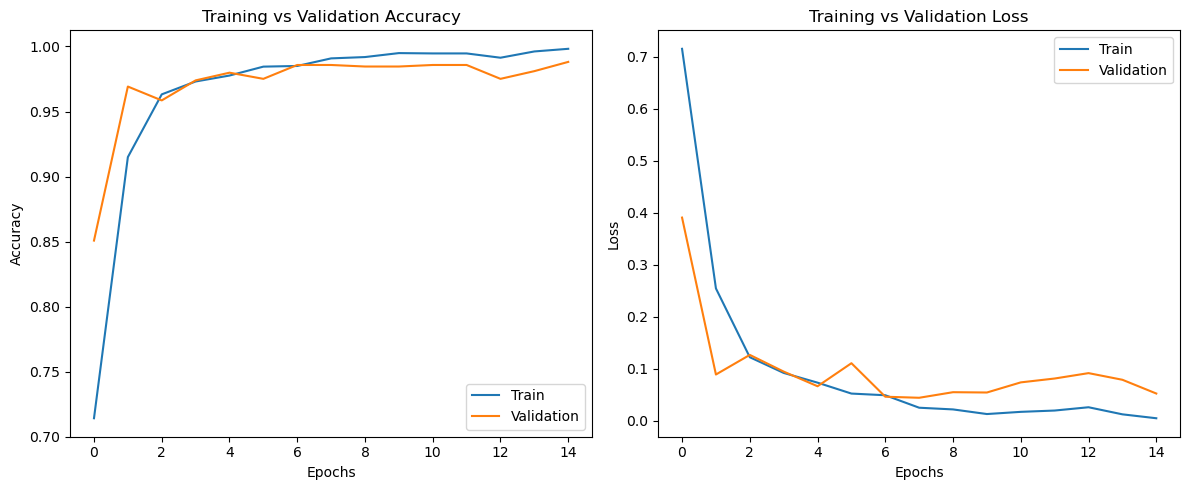

Training curves saved!


In [7]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.tight_layout()

plt.savefig(os.path.join(TRAINING_PATH, "training_curves.png"))

plt.show()

print("Training curves saved!")

In [8]:
print("\nEvaluating model...")

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

with open(os.path.join(EVAL_PATH, "test_accuracy.txt"), "w") as f:
    f.write(f"Test Accuracy: {test_accuracy}\n")
    f.write(f"Test Loss: {test_loss}\n")



Evaluating model...
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9810 - loss: 0.1683
Test Accuracy: 0.9810426831245422
Test Loss: 0.16826841235160828


In [9]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step


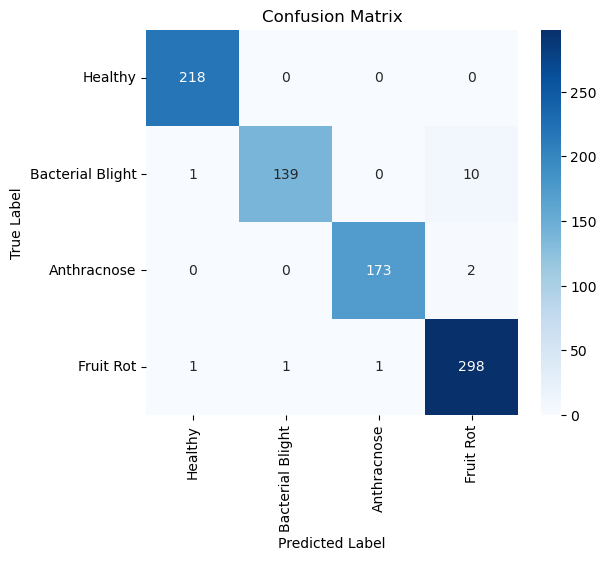

Confusion matrix saved!


In [10]:
class_names = [
    "Healthy",
    "Bacterial Blight",
    "Anthracnose",
    "Fruit Rot"
]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix.png"))

plt.show()

print("Confusion matrix saved!")


In [11]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print("\nClassification Report\n")
print(report)

with open(os.path.join(EVAL_PATH, "classification_report.txt"), "w") as f:
    f.write(report)

print("Classification report saved!")


print("\n CNN Baseline Training Complete")


Classification Report

                  precision    recall  f1-score   support

         Healthy       0.99      1.00      1.00       218
Bacterial Blight       0.99      0.93      0.96       150
     Anthracnose       0.99      0.99      0.99       175
       Fruit Rot       0.96      0.99      0.98       301

        accuracy                           0.98       844
       macro avg       0.98      0.98      0.98       844
    weighted avg       0.98      0.98      0.98       844

Classification report saved!

 CNN Baseline Training Complete
